In [1]:
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "12"
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

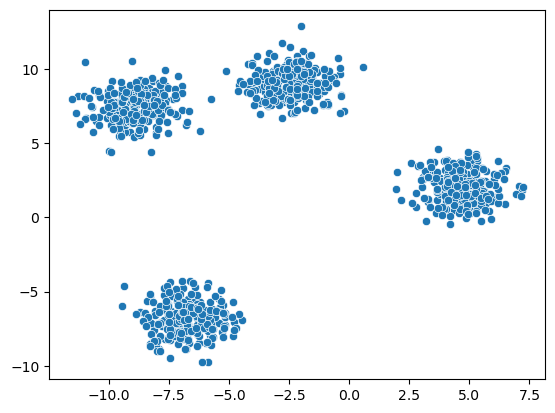

In [4]:
# Visualize
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
)

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [6]:
K = 4

model = KMeans(
    n_clusters=K,
    random_state=42
)

In [7]:
labels = model.fit_predict(X)
# label = cluster number

<Axes: >

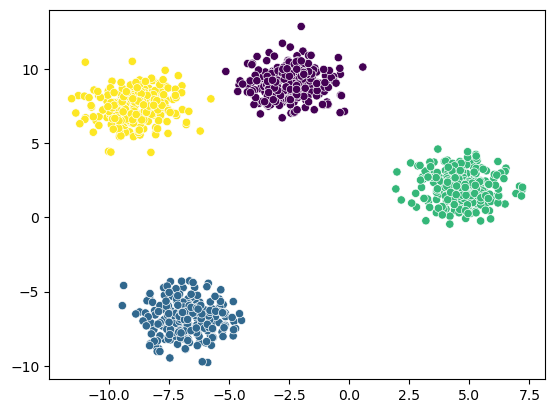

In [8]:
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    c=labels
)

# Choose our K value - Elbow Method, Silhouette Score

In [9]:
# Elbow Method (Manually)

wcss = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

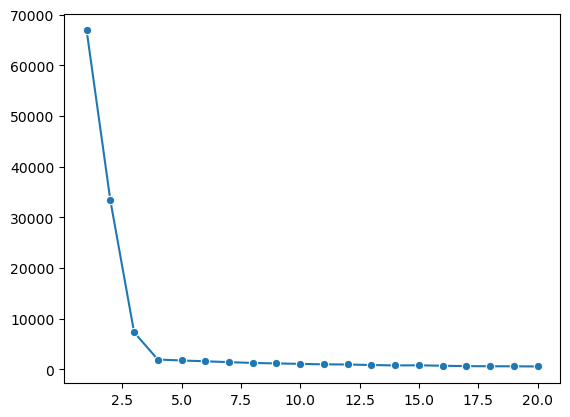

In [10]:
sns.lineplot(x=range(1,21), y=wcss, marker='o')

In [11]:
# Elbow Method (Automate)

!pip install kneed

In [12]:
from kneed import KneeLocator

In [16]:
knee = KneeLocator(range(1, 21), wcss, curve="convex", direction="decreasing")

In [17]:
print("Optimal K = ",knee.elbow)

Optimal K =  4


In [21]:
# Silhouette Score
from sklearn.metrics import silhouette_score

In [22]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

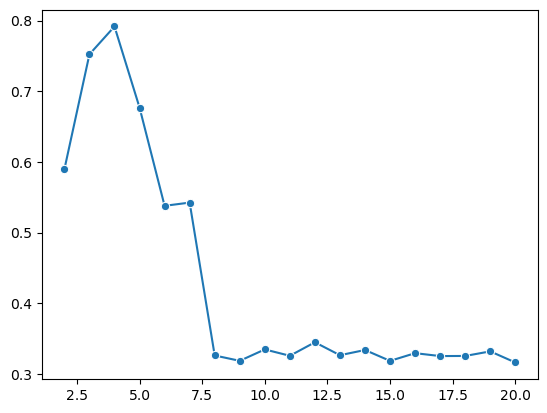

In [23]:
# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')